Data generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC

M = 2
R = np.array([3, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
var_00 = np.array([1])

# Profile (0, 0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-0.2])
var_01 = np.array([1])

# Profile (0, 1, 0)
sigma_10 = np.array([[1]])
mu_10 = np.array([0.1])
var_10 = np.array([1])

# Profile (0, 1, 1)
sigma_11 = np.array([[1], [0]])
mu_11 = np.array([0.2, -0.1])
var_11 = np.array([1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

In [2]:
policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

In [3]:
def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

In [4]:
num_samples_per_feature = 500

X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)

In [5]:
H = np.inf
theta = 8
lamb = 1
R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

(0, 0) 7.101991986884734
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.232312810753831
Adaptive
Profile (0, 1) took 0.00098419189453125 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.223430925891213
Adaptive
Profile (1, 0) took 0.0008459091186523438 s adaptively
Profile (1, 0) has 2 objects in Rashomon set
(1, 1) 7.451694073082411
Adaptive
Profile (1, 1) took 0.0026519298553466797 s adaptively
Profile (1, 1) has 4 objects in Rashomon set
Finding feasible combinations
Min = 5.003842023434152, Max = 9.996856734462604


In [6]:
anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
score_s = AIS.make_score_s_expneg_raw(
    D=D,
    y=y,
    M=M,
    R=R,
    prof_idx_of_policy = prof_idx_of_policy,
    policies=all_policies,
    policy_means=policy_means,
    reg=lamb,
    lattice_edges=None,   # or your edges
    beta=1.0,             # exp(-loss)
    prior_logprob=lambda state: 0.0
)

In [11]:
log_alpha = [score_s(A) for A in anchors]
mcmc_res = MCMC.run_mcmc(score_s, RPS_states, log_alpha, n_chains=1, steps=50000, burnin=500, thin=5, seed=2, min_len=1)

(<Figure size 500x500 with 1 Axes>,
 <Axes: xlabel='True y', ylabel='Posterior predictive of y'>)

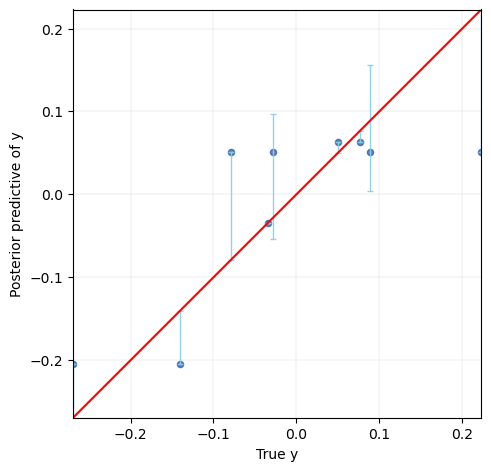

In [12]:
df = MCMC.policy_means_matrix_from_mcmc(
    mcmc_res,
    all_policies,                     # global list/array of policies (length P)
    policy_means,                 # np.ndarray [P,2] = [sum_y, count]
    prof_idx_of_policy,           # length-P array: policy_id -> profile k
    R_per=R,                        # np.ndarray of arm levels (includes control)
    M=M,
    lattice_edges=None,           # pass None if unused
    policy_labels=None            # optional column names; defaults to policy indices (0..P-1)
)

out = MCMC.summarize_policy_means(df)

MCMC.plot_pred_vs_true(out,                         # output from summarize_policy_means
                      policy_means,
                      point_alpha=0.6,
                      point_color="#0b3d91",     # dark blue
                      bar_color="#87ceeb",       # sky blue
                      line_color="red",
                      figsize=(5,5))